# Do Vietnam's Tree Cores give a valuable proxy on ENSO events?
## In this project I will be using data gathered from Tree Cores in Vietnam to see if it can be used as an accurate proxy for ENSO events based on Precipitation and Temperature Data. I also want to show how the rainy and dry seasons have changed geographically from the start of the data set (1901) to the most recent date (2019)
## My hypothesis is that the data will show a relationship with ENSO events, for example, increased temperatures and lower precipitation during an El Nino event and decreased temperatures and increased precipitation during a La Nina event. 

#### Data Wrangling and Manipulation

In [46]:
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import numpy as np
import cartopy
import cartopy.crs as ccrs

In [189]:
pre = pd.read_csv('/home/enh2134/assignments/Final/pre.csv')
crn = pd.read_csv('/home/enh2134/assignments/Final/crn.csv')
tmp = pd.read_csv('/home/enh2134/assignments/Final/tmp.csv')
vap = pd.read_csv('/home/enh2134/assignments/Final/vap.csv')

In [190]:
pre["time"] = pd.to_datetime(dict(year=pre['year'], month=pre['month'], day=1))
pre = pre.drop(columns=["year", "month"])

pre = pre.set_index(["time", "lat", "lon"]).sort_index()

pre_ds = xr.Dataset.from_dataframe(pre)

pre_ds["lat"].attrs = {"units": "degrees_north", "long_name": "latitude"}
pre_ds["lon"].attrs = {"units": "degrees_east", "long_name": "longitude"}
pre_ds["pre"].attrs = {"long_name": "precipitation"}

In [50]:
tmp["time"] = pd.to_datetime(dict(year=tmp["year"], month=tmp["month"], day=1))
tmp = tmp.drop(columns=['year', 'month'])

tmp = tmp.set_index(["time", "lat", "lon"]).sort_index()

tmp_ds = xr.Dataset.from_dataframe(tmp)

tmp_ds["lat"].attrs = {"units": "degrees_north", "long_name": "latitude"}
tmp_ds["lon"].attrs = {"units": "degrees_east", "long_name": "longitude"}
tmp_ds["tmp"].attrs = {"long_name": "temperature"}

vap["time"] = pd.to_datetime(dict(year=vap["year"], month=vap["month"], day=1))
vap = vap.drop(columns=['year', 'month'])

vap = vap.set_index(["time", "lat", "lon"]).sort_index()

vap_ds = xr.Dataset.from_dataframe(vap)

vap_ds["lat"].attrs = {"units": "degrees_north", "long_name": "latitude"}
vap_ds["lon"].attrs = {"units": "degrees_east", "long_name": "longitude"}
vap_ds["vap"].attrs = {"long_name": "vaporization"}

In [51]:
lat = pre_ds["lat"]
lon = pre_ds["lon"]
dataJan1901 = pre_ds['pre'].sel(time = '1901-01-01')
dataOct1901 = pre_ds['pre'].sel(time = '1901-10-01')
dataJan2019 = pre_ds['pre'].sel(time = '2019-01-01')
dataOct2019 = pre_ds['pre'].sel(time = '2019-10-01')

In [53]:
latT = tmp_ds["lat"]
lonT = tmp_ds["lon"]
dataTJan1901 = tmp_ds['tmp'].sel(time = '1901-01-01')
dataTOct1901 = tmp_ds['tmp'].sel(time = '1901-10-01')
dataTJan2019 = tmp_ds['tmp'].sel(time = '2019-01-01')
dataTOct2019 = tmp_ds['tmp'].sel(time = '2019-10-01')

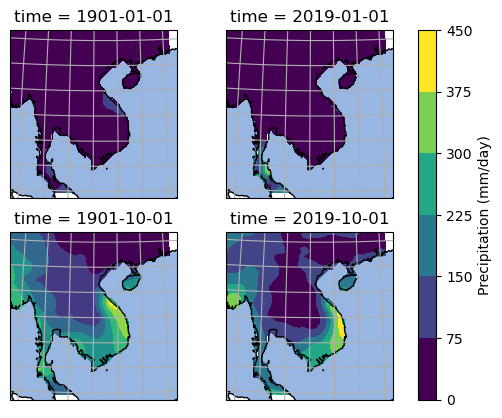

In [188]:
fig, axes = plt.subplots(nrows=2, ncols=2,
                         subplot_kw={'projection': ccrs.Orthographic(central_lon, central_lat)})

datasets = [dataJan1901, dataJan2019, dataOct1901, dataOct2019]  
positions = [(0,0), (0,1), (1,0), (1,1)]


for data, (row, col) in zip(datasets, positions):
    ax = axes[row, col]
    ax.set_extent(extent)
    ax.gridlines()
    ax.coastlines(resolution='50m')
    ax.add_feature(cartopy.feature.OCEAN)
    cb = data.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), vmin=0, vmax=450, add_colorbar=False)
    
    
fig.colorbar(cb, ax=axes, orientation='vertical', label ='Precipitation (mm/day)')
plt.show()

## Here you can see that comparing the beginning and end of the data set for precipitation shows that the rainy season (October) is more concentrated in comparison to 1901. 2019 is a weak El Nino year so the increased precipitation that year is actually slightly lower than a normal year. The rain is more coastal and more intense on the East Coast of South East Asia than a more even precipitation pattern in 1901. The dry season aslo appears to be slightly more dry, but this is likely not significant.

In [180]:
nina = [pd.Timestamp('1973-11-01'), pd.Timestamp('1975-11-01'), 
        pd.Timestamp('1988-11-01'), pd.Timestamp('1999-11-01'), 
        pd.Timestamp('2007-11-01'), pd.Timestamp('2010-11-01'),
       pd.Timestamp('1955-11-01'), pd.Timestamp('1970-11-01'),
       pd.Timestamp('1995-11-01'), pd.Timestamp('2011-11-01')]

nino = [pd.Timestamp('1982-11-01'), pd.Timestamp('2016-11-01'), pd.Timestamp('1997-11-01'), 
             pd.Timestamp('1957-11-01'), pd.Timestamp('1965-11-01'), pd.Timestamp('1972-11-01'), 
             pd.Timestamp('1987-11-01'), pd.Timestamp('1991-11-01')]

### These are the years of moderate to strong ENSO events, with the recorded record starting at 1950. 

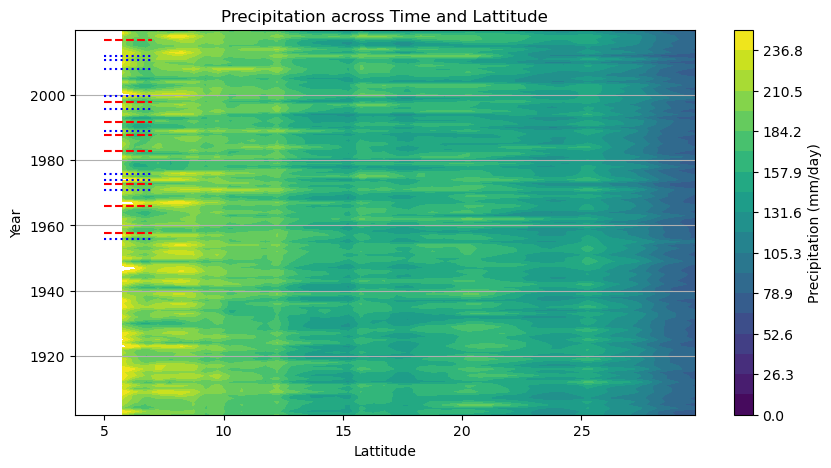

In [191]:
#average across lattitude
yearly = pre_ds['pre'].resample(time ='YE').mean()

fig, ax = plt.subplots(figsize=(10, 5))
levels = np.linspace(0, 250, 20)
cf = ax.contourf(yearly.lat, yearly.time, yearly.mean(dim="lon"), levels)
cbar = fig.colorbar(cf, ax=ax, label='Precipitation (mm/day)')
ax.set_title('Precipitation across Time and Lattitude')
ax.set_ylabel('Year')
ax.set_xlabel('Lattitude')
ax.hlines(y=nina, xmin=5, xmax=7, colors='blue', linestyles='dotted')
ax.hlines(y=nino, xmin=5, xmax=7, colors='red', linestyles='dashed')
ax.grid(axis='y')

### Here is the precipitation record over lattitude and time. You can see the rainy bands of lattitude as well as different color patterns of yearly precipitation. The Red Lines correspond with El Nino events and the Blue with La Nina. The lines were kept short to allow the colors to show through. Using the lines you can see how the ENSO events affect precipitation with La Nina events increase the rainy season. Comparing the recorded ENSO events with pre 1950s allows us to see where the precipitation events reflected in the historical tree ring record occurred, including ENSOs.  

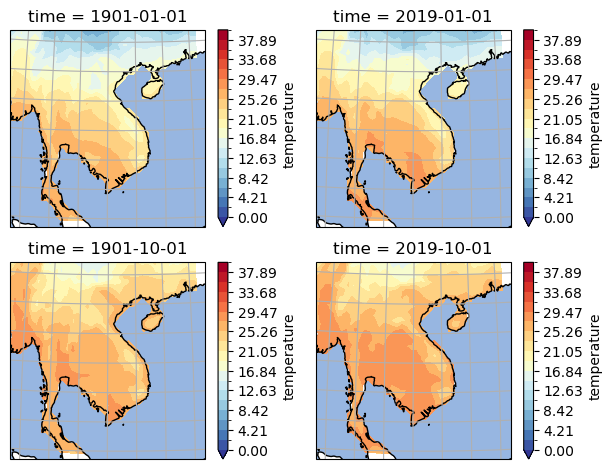

In [185]:
fig, axes = plt.subplots(nrows=2, ncols=2,
                         subplot_kw={'projection': ccrs.Orthographic(central_lon, central_lat)})

datasetsT = [dataTJan1901, dataTJan2019, dataTOct1901, dataTOct2019]  
positions = [(0,0), (0,1), (1,0), (1,1)]

for data, (row, col) in zip(datasetsT, positions):
    ax = axes[row, col]
    ax.set_extent(extent)
    ax.gridlines()
    ax.coastlines(resolution='50m')
    ax.add_feature(cartopy.feature.OCEAN)
    data.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                      vmin=0, vmax=40, levels=20, cmap='RdYlBu_r' ) 

plt.tight_layout()
plt.show()

## This figure shows the change in temperature from the start of the data to the end. You can see that in 2019 there is more areas of high temperature when compared with 1901. In the winter, you can see that the cold has also recessed further north. Again, 2019 was a weak El Nino event, so temperatures might be slightly lower than seen here.

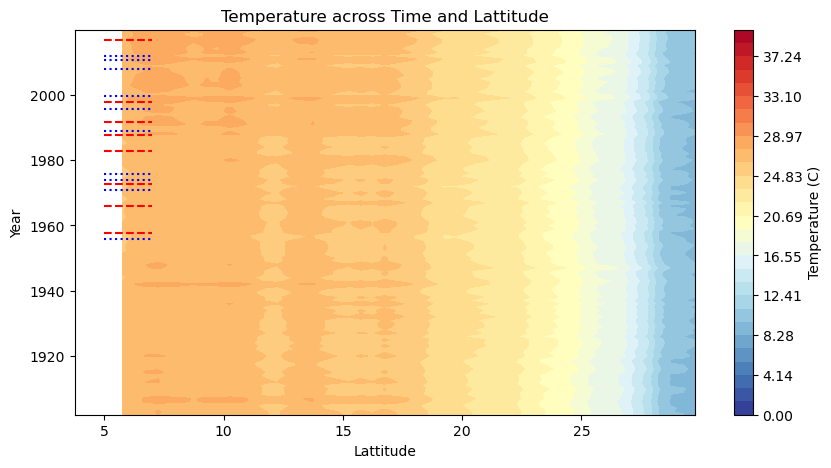

In [187]:
yearlyT = tmp_ds['tmp'].resample(time ='YE').mean()

fig, ax = plt.subplots(figsize=(10, 5))
levels = np.linspace(0, 40, 30)
cf = ax.contourf(yearlyT.lat, yearlyT.time, yearlyT.mean(dim="lon"), levels, cmap= 'RdYlBu_r')
cbar = fig.colorbar(cf, ax=ax, label='Temperature (C)')
ax.set_title('Temperature across Time and Lattitude')
ax.set_ylabel('Year')
ax.set_xlabel('Lattitude')
ax.hlines(y=nina, xmin=5, xmax=7, colors='blue', linestyles='dotted')
ax.hlines(y=nino, xmin=5, xmax=7, colors='red', linestyles='dashed')

## In this figure you can see the evolution of warming global temperatures, as the colder temperatures are gradually slimming and higher temepratures are more frequent in recent years. Due to global warming to successfully see an ENSO event we need to look at anomalies or detrended data to gain a clearer picture without the trend hiding data. 

In [172]:
latV = vap_ds["lat"]
lonV = vap_ds["lon"]
dataVJan1901 = vap_ds['vap'].sel(time = '1901-01-01')
dataVOct1901 = vap_ds['vap'].sel(time = '1901-10-01')
dataVJan2019 = vap_ds['vap'].sel(time = '2019-01-01')
dataVOct2019 = vap_ds['vap'].sel(time = '2019-10-01')

## Looking to see if the strong ENSO events are reflected in the Tree Ring record allow for a better assessment to be made about historical events. Temperature anomalies are easier viewed in the following format

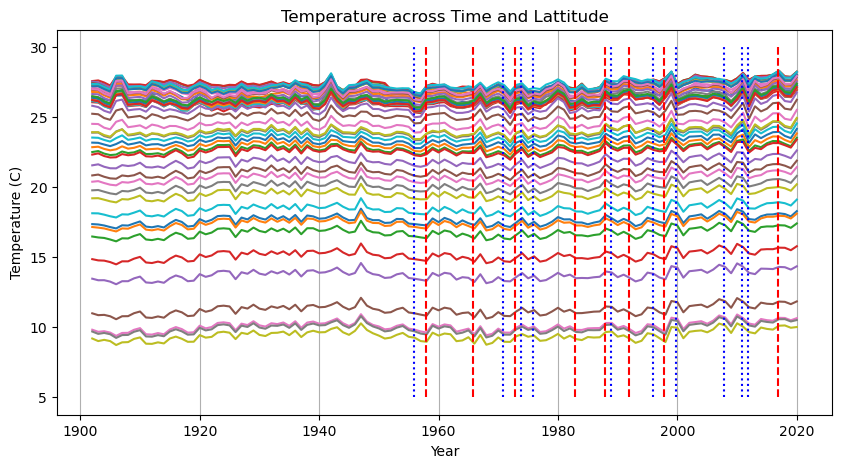

In [196]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearlyT.time, yearlyT.mean(dim='lon'))
ax.set_title('Temperature across Time and Lattitude')
ax.set_ylabel('Temperature (C)')
ax.set_xlabel('Year')

ax.vlines(x=nino, ymin=5, ymax=30, colors='red', linestyles='dashed')

ax.vlines(x=nina, ymin=5, ymax=30, colors='blue', linestyles='dotted')
ax.grid(axis='x')

## Using the known record of moderate to strong ENSO events starting at 1950, we can see that there are are temperature anomalies accociated with the tree ring record during recorded ENSO events. Looking at the graph we can see that there are other events that can likely be analyzed to have experienced ENSO events using tree ring data from Vietnam. 
## Possible ENSO events appear at 1950, 1941, 1925, 1910. You can see these reflected in both precipitation and temperature visualizations over time 

### With proper statistical tests we would be able to analyze if there is a proper p value. Combined with detrending the data we could see how the extent of ENSO events in Vietnam and measure the severity. Overall the tree cores in Vietnam appear to be a good proxy for historical ENSO events when combining factors such as precipitation and temperature. This can also be used as a vizualisation tool for climate modeling, both historical and theoretical. With the cartopy package, we can combine them together over the range of time to show accurately how ENSO events affect SE Asia. And with worsening effects of climate change, this could be used to help shape future climate models for worsening severity. 